In [2]:
import torchvision
from torchvision import transforms

train_dataset_raw = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True
)
test_dataset_raw = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True
)


c:\github_repos\nebius_ai_performance_engineering\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
import numpy as np
import pandas as pd

In [4]:
class_names = train_dataset_raw.classes

train_images = train_dataset_raw.data
test_images = test_dataset_raw.data
train_labels = np.array(train_dataset_raw.targets)
test_labels = np.array(test_dataset_raw.targets)

# flatten images so that each object is represented as a vector
train_flat = train_images.reshape(len(train_images), -1)
test_flat = test_images.reshape(len(test_images), -1)

train_data = pd.DataFrame(train_flat)
train_data['label'] = train_labels

test_data = pd.DataFrame(test_flat)
test_data['label'] = test_labels

train_data.head()


,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,59,62,63,43,46,45,50,48,43,68,...,216,184,140,151,118,84,123,92,72,6
1,154,177,187,126,137,136,105,104,95,102,...,143,133,139,143,134,142,143,133,144,9
2,255,255,255,253,253,253,253,253,253,253,...,78,85,83,79,85,83,80,86,84,9
3,28,25,10,37,34,19,38,35,20,42,...,54,47,28,63,56,37,72,65,46,4
4,170,180,198,168,178,196,177,185,203,183,...,75,79,82,71,75,78,73,77,80,1


In [5]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # define layers and activation function that your model will have
        self.fc1 = nn.Linear(3072, 256)  # Input: 32*32*3 = 3072 flattened pixels
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, 1)       # Output: 1 neuron for binary classification
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()       # Sigmoid for probability output


    def forward(self, x):

        # define a flow of input through your layers
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))     # Output probability of class 1

        return x

In [6]:
import torch

# Set up device for GPU acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"\n--- GPU Information ---")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Count: {torch.cuda.device_count()}")
    print(f"Current GPU Index: {torch.cuda.current_device()}")
    print(f"GPU Memory Allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")
    print(f"GPU Memory Cached: {torch.cuda.memory_reserved(0) / 1024**2:.2f} MB")
    print(f"GPU Total Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"cuDNN Version: {torch.backends.cudnn.version()}")
else:
    print("\nNo GPU available, using CPU.")

Using device: cuda

--- GPU Information ---
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
GPU Count: 1
Current GPU Index: 0
GPU Memory Allocated: 0.00 MB
GPU Memory Cached: 0.00 MB
GPU Total Memory: 4.00 GB
CUDA Version: 13.0
cuDNN Version: 91900


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader

In [8]:
class CIFAR10Dataset(Dataset):
    def __init__(self, data):
        '''
        params:
            data (pd.DataFrame) â€” dataframe with flattened CIFAR-10 images and column `label`
        '''

        # load the data and
        # split it into features and target variable
        # and convert both to np.array
        # please do not change names of variables self.X and self.y,
        # it is important for the checks below to work correctly

        # features
        self.X = data.drop(columns=['label']).values
        # target variable
        self.y = data['label'].values

    def __len__(self):
        '''
        method that returns the number of objects in a dataset.
        This method is used by dataloader to generate batches of data
        '''
        return len(self.X)

    def __getitem__(self, idx):
        '''
        method that, given an index idx, returns the dataset object
        corresponding to the index.
        This method is used by dataloader to form batches of data
        params:
            idx: index of an element of the data
        '''

        # - get an object of data by index idx;
        # - normalize features (divide each pixel by 255.);
        # - convert features and target to tensor
        features = self.X[idx] / 255.
        target = self.y[idx]
        
        return torch.tensor(features, dtype=torch.float32), torch.tensor(target, dtype=torch.long)

In [9]:
cifar_train_dataset = CIFAR10Dataset(train_data)
cifar_test_dataset = CIFAR10Dataset(test_data)


In [10]:
train_loader = torch.utils.data.DataLoader(cifar_train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(cifar_test_dataset, batch_size=64, shuffle=False)


In [11]:
def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader â€” structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''

    # arrays for storing loss values, network predictions and true values
    losses = []
    y_pred_list = []
    y_true_list = []

    model.eval()

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch
            y_pred = model(X_batch)

            # calculate loss function
            loss = criterion(y_pred, y_batch)
            losses.append(loss.item())


        # convert outputs of your network into class number
        y_pred = torch.argmax(y_pred, dim=1).tolist()

        # save for accuracy calculation
        y_pred_list.extend(y_pred)
        y_true_list.extend(y_batch.tolist())

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = sum(1 for p, t in zip(y_pred_list, y_true_list) if p == t) / len(y_true_list)

    return np.mean(losses), accuracy

[I 2026-04-15 19:20:57,895] A new study created in memory with name: no-name-dcc2e062-b273-49b4-9ca7-f86949e9e707


CONSTANTS
  N Trials:            2
  Num Epochs:          100
  Early Stop Patience: 15
TRIAL 1 HYPERPARAMETERS
  Learning Rate:       0.0007958625163426187
  Batch Size:          256
  Optimizer:           adam
  Weight Decay:        2.8175935523807695e-06
  Hidden Sizes:        (307, 66, 89)
  Batch Norm:          False
  Dropout Rate:        0.10961392294424604
Epoch   1/100  Train Loss: 2.0064  Eval Loss: 1.8295  Eval Acc: 0.3411
Epoch   5/100  Train Loss: 1.6536  Eval Loss: 1.5755  Eval Acc: 0.4451
Epoch  10/100  Train Loss: 1.5292  Eval Loss: 1.5236  Eval Acc: 0.4635
Epoch  15/100  Train Loss: 1.4548  Eval Loss: 1.4415  Eval Acc: 0.4779
Epoch  20/100  Train Loss: 1.3995  Eval Loss: 1.4342  Eval Acc: 0.4838
Epoch  25/100  Train Loss: 1.3392  Eval Loss: 1.3967  Eval Acc: 0.5028
Epoch  30/100  Train Loss: 1.3109  Eval Loss: 1.3589  Eval Acc: 0.5083
Epoch  35/100  Train Loss: 1.2563  Eval Loss: 1.3625  Eval Acc: 0.5188
Epoch  40/100  Train Loss: 1.2261  Eval Loss: 1.3341  Eval Acc: 0

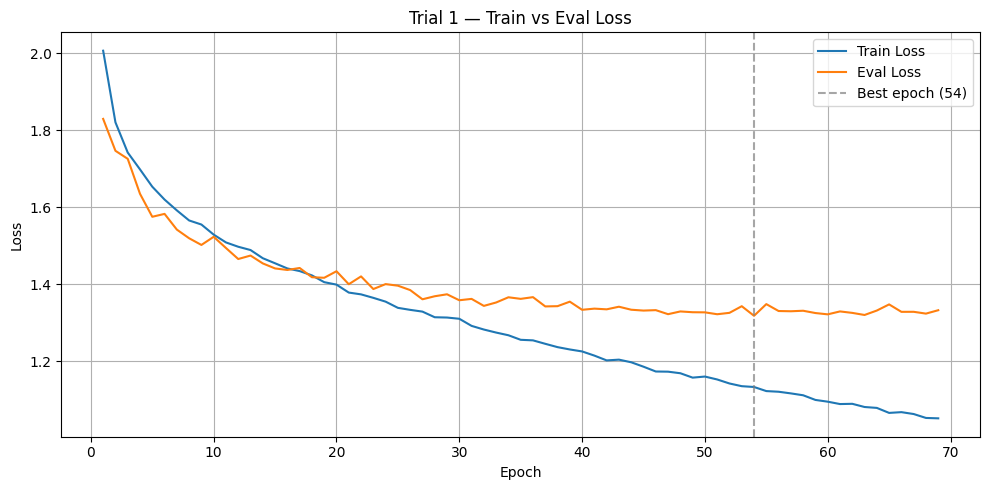

[I 2026-04-15 19:25:52,831] Trial 0 finished with value: 1.3185679733753204 and parameters: {'learning_rate': 0.0007958625163426187, 'batch_size': 256, 'optimizer': 'adam', 'weight_decay': 2.8175935523807695e-06, 'dropout_rate': 0.10961392294424604, 'use_batch_norm': False, 'num_layers': 3, 'layer_0_width': 307, 'layer_1_width': 66, 'layer_2_width': 89}. Best is trial 0 with value: 1.3185679733753204.



FINAL RESULTS (best model from epoch 54)
  Split         Loss  Accuracy
  Train       0.9104    0.6723
  Eval        1.3331    0.5430
  Test        1.3318    0.5370
TRIAL 2 HYPERPARAMETERS
  Learning Rate:       0.0038065999159847806
  Batch Size:          256
  Optimizer:           adam
  Weight Decay:        1.1183296340767193e-05
  Hidden Sizes:        (178, 622, 135, 186, 604)
  Batch Norm:          True
  Dropout Rate:        0.29693238174754377
Epoch   1/100  Train Loss: 1.9095  Eval Loss: 1.7422  Eval Acc: 0.3698
Epoch   5/100  Train Loss: 1.5191  Eval Loss: 1.5044  Eval Acc: 0.4566
Epoch  10/100  Train Loss: 1.3734  Eval Loss: 1.4713  Eval Acc: 0.4795
Epoch  15/100  Train Loss: 1.2887  Eval Loss: 1.4207  Eval Acc: 0.4995
Epoch  20/100  Train Loss: 1.2146  Eval Loss: 1.3801  Eval Acc: 0.5160
Epoch  25/100  Train Loss: 1.1616  Eval Loss: 1.4580  Eval Acc: 0.4969
Epoch  30/100  Train Loss: 1.1090  Eval Loss: 1.3902  Eval Acc: 0.5108
Epoch  35/100  Train Loss: 1.0518  Eval Loss: 1

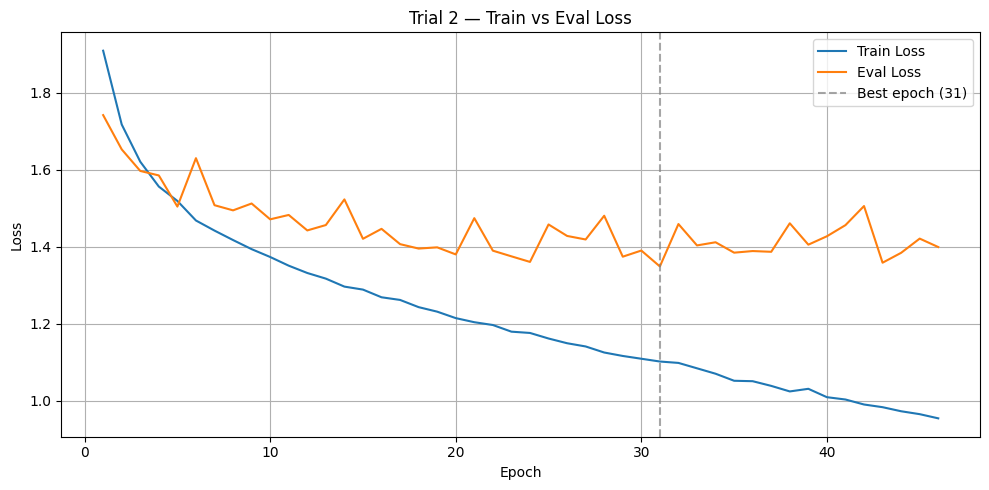

[I 2026-04-15 19:29:22,291] Trial 1 finished with value: 1.3488825052976607 and parameters: {'learning_rate': 0.0038065999159847806, 'batch_size': 256, 'optimizer': 'adam', 'weight_decay': 1.1183296340767193e-05, 'dropout_rate': 0.29693238174754377, 'use_batch_norm': True, 'num_layers': 5, 'layer_0_width': 178, 'layer_1_width': 622, 'layer_2_width': 135, 'layer_3_width': 186, 'layer_4_width': 604}. Best is trial 0 with value: 1.3185679733753204.



FINAL RESULTS (best model from epoch 31)
  Split         Loss  Accuracy
  Train       0.8014    0.7188
  Eval        1.3993    0.5310
  Test        1.4012    0.5238

OPTUNA BEST TRIAL
  Trial Number: 1
  Best Eval Loss: 1.3186
  Params:
    learning_rate: 0.0007958625163426187
    batch_size: 256
    optimizer: adam
    weight_decay: 2.8175935523807695e-06
    dropout_rate: 0.10961392294424604
    use_batch_norm: False
    num_layers: 3
    layer_0_width: 307
    layer_1_width: 66
    layer_2_width: 89


In [13]:
import matplotlib.pyplot as plt
import optuna
from torch.utils.data import random_split

# ============================================================
# OPTUNA SEARCH CONFIGURATION
# ============================================================
N_TRIALS = 2
NUM_EPOCHS = 100
EARLY_STOP_PATIENCE = 15

SEARCH_SPACE = {
    'learning_rate':   (1e-4, 1e-1, True),    # (low, high, log_scale)
    'batch_size':      [64, 128, 256, 512],    # categorical
    'optimizer':       ['sgd_momentum', 'adam', 'adamw'],
    'weight_decay':    (1e-6, 1e-2, True),
    'dropout_rate':    (0.0, 0.5),             # (low, high)
    'use_batch_norm':  [True, False],
    'num_layers':      (1, 5),                 # (min, max) int
    'layer_width_min': 64,                     # min width for any layer
    'layer_width_max': 1024,                   # max width for any layer
}

# ============================================================
# Print constants
# ============================================================
print("=" * 50)
print("CONSTANTS")
print("=" * 50)
print(f"  N Trials:            {N_TRIALS}")
print(f"  Num Epochs:          {NUM_EPOCHS}")
print(f"  Early Stop Patience: {EARLY_STOP_PATIENCE}")
print("=" * 50)

# ============================================================
# Train / Eval / Test split (80/20 from original training set)
# (done once, shared across all trials)
# ============================================================
train_size = int(0.8 * len(cifar_train_dataset))
eval_size = len(cifar_train_dataset) - train_size
train_subset, eval_subset = random_split(
    cifar_train_dataset, [train_size, eval_size],
    generator=torch.Generator().manual_seed(42),
)


# ============================================================
# Objective function for Optuna
# ============================================================
def objective(trial):
    # --- Sample hyperparameters ---
    lr_low, lr_high, lr_log = SEARCH_SPACE['learning_rate']
    LEARNING_RATE = trial.suggest_float('learning_rate', lr_low, lr_high, log=lr_log)
    BATCH_SIZE = trial.suggest_categorical('batch_size', SEARCH_SPACE['batch_size'])
    OPTIMIZER_NAME = trial.suggest_categorical('optimizer', SEARCH_SPACE['optimizer'])
    wd_low, wd_high, wd_log = SEARCH_SPACE['weight_decay']
    WEIGHT_DECAY = trial.suggest_float('weight_decay', wd_low, wd_high, log=wd_log)
    DROPOUT_RATE = trial.suggest_float('dropout_rate', *SEARCH_SPACE['dropout_rate'])
    USE_BATCH_NORM = trial.suggest_categorical('use_batch_norm', SEARCH_SPACE['use_batch_norm'])
    n_layers = trial.suggest_int('num_layers', *SEARCH_SPACE['num_layers'])
    HIDDEN_SIZES = tuple(
        trial.suggest_int(
            f'layer_{i}_width',
            SEARCH_SPACE['layer_width_min'],
            SEARCH_SPACE['layer_width_max'],
            log=True,
        )
        for i in range(n_layers)
    )

    # ============================================================
    # Print hyperparameters
    # ============================================================
    print("=" * 50)
    print(f"TRIAL {trial.number + 1} HYPERPARAMETERS")
    print("=" * 50)
    print(f"  Learning Rate:       {LEARNING_RATE}")
    print(f"  Batch Size:          {BATCH_SIZE}")
    print(f"  Optimizer:           {OPTIMIZER_NAME}")
    print(f"  Weight Decay:        {WEIGHT_DECAY}")
    print(f"  Hidden Sizes:        {HIDDEN_SIZES}")
    print(f"  Batch Norm:          {USE_BATCH_NORM}")
    print(f"  Dropout Rate:        {DROPOUT_RATE}")
    print("=" * 50)

    # ============================================================
    # Data loaders
    # ============================================================
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    eval_loader = DataLoader(eval_subset, batch_size=BATCH_SIZE, shuffle=False)

    # ============================================================
    # Model definition
    # ============================================================

    class FlexibleNet(nn.Module):
        """
        Fully-connected network with configurable:
          - hidden layer sizes (and thus number of layers)
          - dropout rate
          - batch normalisation on/off
        All arguments map 1-to-1 to Optuna-tunable hyperparameters.
        """
        def __init__(self, hidden_sizes, use_batch_norm, dropout_rate):
            super().__init__()
            layers = []
            in_features = 3072  # CIFAR-10 flattened: 32*32*3
            for h in hidden_sizes:
                layers.append(nn.Linear(in_features, h))
                if use_batch_norm:
                    layers.append(nn.BatchNorm1d(h))
                layers.append(nn.ReLU())
                if dropout_rate > 0:
                    layers.append(nn.Dropout(dropout_rate))
                in_features = h
            layers.append(nn.Linear(in_features, 10))
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x)


    def build_optimizer(model, optimizer_name, lr, weight_decay):
        """Return optimizer. Easy to extend for Optuna."""
        if optimizer_name == 'sgd_momentum':
            return torch.optim.SGD(model.parameters(), lr=lr,
                                   momentum=0.9, weight_decay=weight_decay)
        elif optimizer_name == 'adam':
            return torch.optim.Adam(model.parameters(), lr=lr,
                                    weight_decay=weight_decay)
        elif optimizer_name == 'adamw':
            return torch.optim.AdamW(model.parameters(), lr=lr,
                                     weight_decay=weight_decay)
        else:
            raise ValueError(f"Unknown optimizer: {optimizer_name}")

    # ============================================================
    # Training loop with early stopping
    # ============================================================

    model = FlexibleNet(HIDDEN_SIZES, USE_BATCH_NORM, DROPOUT_RATE).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, OPTIMIZER_NAME, LEARNING_RATE, WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    train_losses = []
    eval_losses = []
    best_eval_loss = float('inf')
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(NUM_EPOCHS):
        # --- Train ---
        model.train()
        running_loss = 0.0
        num_batches = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            num_batches += 1
        scheduler.step()
        avg_train_loss = running_loss / num_batches
        train_losses.append(avg_train_loss)

        # --- Evaluate ---
        eval_loss, eval_acc = evaluate(model, eval_loader, criterion)
        eval_losses.append(eval_loss)

        # --- Early stopping ---
        if eval_loss < best_eval_loss:
            best_eval_loss = eval_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            best_model_state = model.state_dict().copy()
        else:
            epochs_without_improvement += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS}  "
                  f"Train Loss: {avg_train_loss:.4f}  "
                  f"Eval Loss: {eval_loss:.4f}  Eval Acc: {eval_acc:.4f}")

        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} "
                  f"(best eval loss {best_eval_loss:.4f} at epoch {best_epoch+1})")
            break

        # --- Optuna pruning ---
        trial.report(eval_loss, epoch)
        if trial.should_prune():
            print(f"\nPruned at epoch {epoch+1}")
            raise optuna.exceptions.TrialPruned()

    # Restore best model
    model.load_state_dict(best_model_state)
    print(f"\nRestored best model from epoch {best_epoch+1}")

    # ============================================================
    # Plot train & eval loss
    # ============================================================
    epochs_ran = len(train_losses)
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, epochs_ran + 1), train_losses, label='Train Loss')
    plt.plot(range(1, epochs_ran + 1), eval_losses, label='Eval Loss')
    plt.axvline(x=best_epoch + 1, color='grey', linestyle='--', alpha=0.7,
                label=f'Best epoch ({best_epoch+1})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Trial {trial.number + 1} — Train vs Eval Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # Final evaluation: train, eval, test accuracy
    # ============================================================
    train_loss_final, train_acc = evaluate(model, train_loader, criterion)
    eval_loss_final, eval_acc = evaluate(model, eval_loader, criterion)
    test_loss_final, test_acc = evaluate(model, test_loader, criterion)

    print(f"\n{'='*50}")
    print(f"FINAL RESULTS (best model from epoch {best_epoch+1})")
    print(f"{'='*50}")
    print(f"  {'Split':<8s}  {'Loss':>8s}  {'Accuracy':>8s}")
    print(f"  {'Train':<8s}  {train_loss_final:8.4f}  {train_acc:8.4f}")
    print(f"  {'Eval':<8s}  {eval_loss_final:8.4f}  {eval_acc:8.4f}")
    print(f"  {'Test':<8s}  {test_loss_final:8.4f}  {test_acc:8.4f}")

    return best_eval_loss


# ============================================================
# Run Optuna study
# ============================================================
study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
)
study.optimize(objective, n_trials=N_TRIALS, n_jobs=1)

# ============================================================
# Print best trial summary
# ============================================================
best_trial = study.best_trial
print("\n" + "=" * 60)
print("OPTUNA BEST TRIAL")
print("=" * 60)
print(f"  Trial Number: {best_trial.number + 1}")
print(f"  Best Eval Loss: {best_trial.value:.4f}")
print(f"  Params:")
for k, v in best_trial.params.items():
    print(f"    {k}: {v}")
print("=" * 60)

C:\Users\karke\AppData\Local\Temp\ipykernel_7304\4013525539.py:12: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = plot_optimization_history(study)


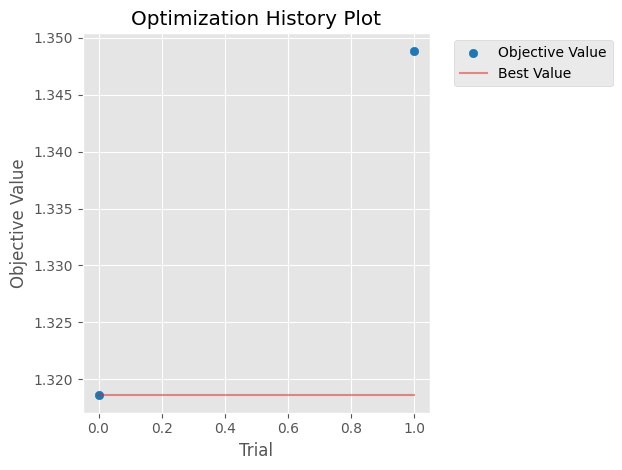

C:\Users\karke\AppData\Local\Temp\ipykernel_7304\4013525539.py:17: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = plot_param_importances(study)


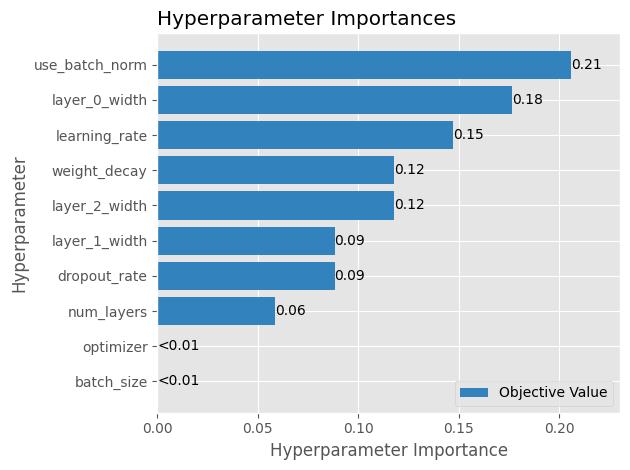

C:\Users\karke\AppData\Local\Temp\ipykernel_7304\4013525539.py:22: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fig = plot_parallel_coordinate(study)
c:\github_repos\nebius_ai_performance_engineering\.venv\Lib\site-packages\optuna\visualization\matplotlib\_parallel_coordinate.py:99: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(info.dim_objective.range[0], info.dim_objective.range[1])
c:\github_repos\nebius_ai_performance_engineering\.venv\Lib\site-packages\optuna\visualization\matplotlib\_parallel_coordinate.py:115: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(dim.range[0], dim.range[1])
c:\github_repos\nebius_ai_performance_engineering\.venv\Lib\site-packages\optuna\visualization\ma

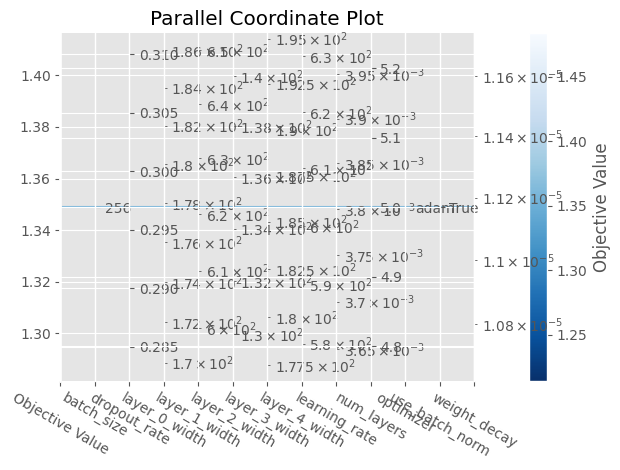

C:\Users\karke\AppData\Local\Temp\ipykernel_7304\4013525539.py:27: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  fig = plot_slice(study)
c:\github_repos\nebius_ai_performance_engineering\.venv\Lib\site-packages\optuna\visualization\matplotlib\_slice.py:146: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(xlim[0], xlim[1])
C:\Users\karke\AppData\Local\Temp\ipykernel_7304\4013525539.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


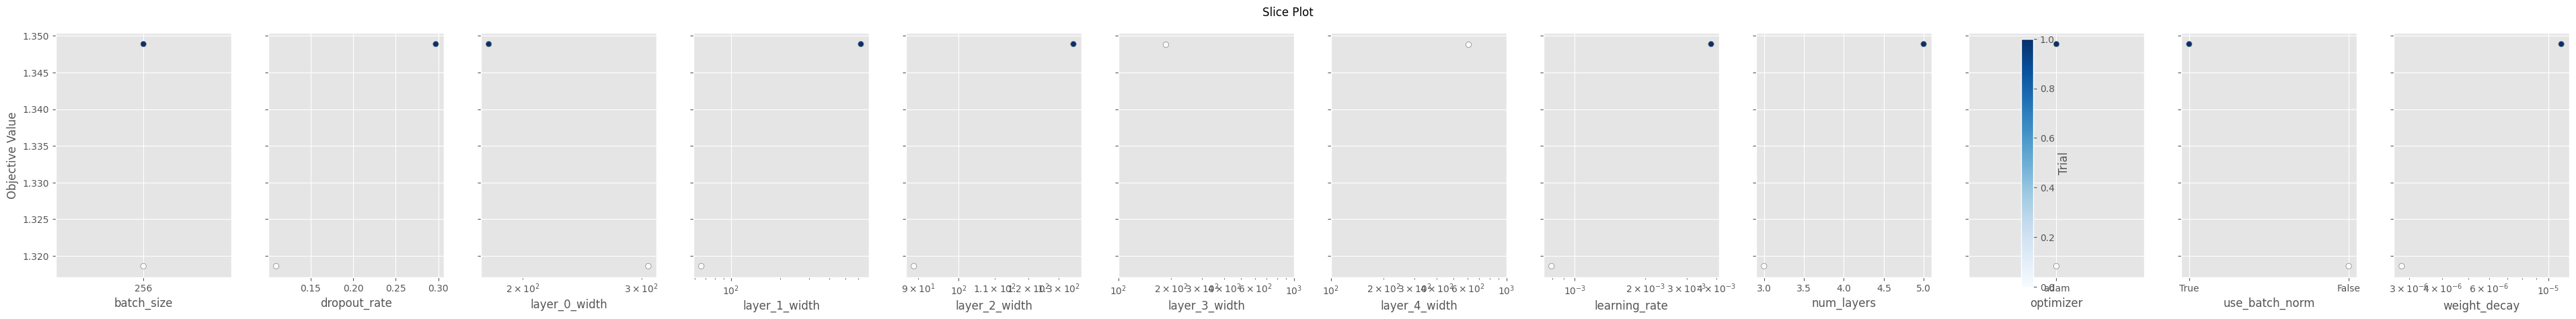

In [14]:
# ============================================================
# Optuna Visualization
# ============================================================
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_slice,
)

# Optimization history
fig = plot_optimization_history(study)
plt.tight_layout()
plt.show()

# Hyperparameter importances
fig = plot_param_importances(study)
plt.tight_layout()
plt.show()

# Parallel coordinate plot
fig = plot_parallel_coordinate(study)
plt.tight_layout()
plt.show()

# Slice plot
fig = plot_slice(study)
plt.tight_layout()
plt.show()